
# Práctica NLP – Sentiment Analysis con reviews de Amazon

### Máster en Deep Learning UPM - Curso 2025/26

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
print("OK")

OK


In [3]:
pip install -r ../requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [fastapi]m7/9 [pydantic]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import re
import string

from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from gensim.models import Word2Vec

from sklearn.svm import SVC

In [5]:
from src.features.preprocessing import clean_base
from src.features.text_features import preprocess_bow
from src.features.text_features import build_bow_matrix, prepare_w2v_tokens
from src.features.text_quality import rare_chars_european
from src.models.train import train_model
from src.models.evaluation import evaluate_model, get_metrics
from src.features.embeddings import review_vector
from src.pipeline import run_experiment



# 1. Carga de datos

In [6]:
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "dataset_practica.csv"

df = pd.read_csv(DATA_PATH)

In [7]:
df

,review_body,language,sentiment_label,product_category
0,"Très contente, j'en ai acheté 2 car mes 2 garç...",fr,positive,pc
1,サイズはピッタリフィットしたけど、実際に使ってみると頭を傾けただけでよく滑り落ちる。 使用感...,ja,negative,electronics
2,livré dans les délais semble solide a voir a l...,fr,positive,automotive
3,Une des deux boîtes des chargeurs était cassée.,fr,negative,camera
4,si ha cumplido mis espectativas.,es,positive,book
...,...,...,...,...
23973,Meine Box ist immer sicher und gut verpackt. 👍,de,positive,wireless
23974,自我暗示，自我激励，关于如何分析问题的书。,zh,negative,digital_ebook_purchase
23975,"Schnelle Lieferung, ausgepackt und so ein edle...",de,positive,home_improvement
23976,上脚没有那么好看，因为很单薄，所以导致有点偏大,zh,positive,shoes


# 2. Exploración de datos (EDA)

## 2.1. Null

El dataset contiene reviews multilingües en seis idiomas, algunos de ellos con sistema de escritura distinto. Revisamos el dataset y no se incluyen valores nulos o faltantes en ninguna columna, por lo que no fue necesario aplicar imputación ni eliminar filas.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23978 entries, 0 to 23977
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   review_body       23978 non-null  str  
 1   language          23978 non-null  str  
 2   sentiment_label   23978 non-null  str  
 3   product_category  23978 non-null  str  
dtypes: str(4)
memory usage: 749.4 KB


## 2.2. Distribución

In [9]:
label_counts = df['sentiment_label'].value_counts()
label_props = df['sentiment_label'].value_counts(normalize=True)

print(label_counts)
print(label_props)

sentiment_label
negative    12031
positive    11947
Name: count, dtype: int64
sentiment_label
negative    0.501752
positive    0.498248
Name: proportion, dtype: float64


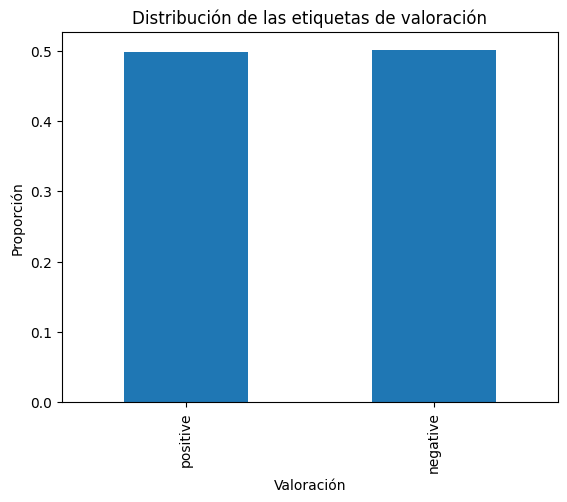

In [10]:
label_props.sort_values().plot(kind='bar')
plt.title('Distribución de las etiquetas de valoración')
plt.ylabel('Proporción')
plt.xlabel('Valoración')
plt.show()

In [11]:
df['language'].value_counts()

language
en    4033
zh    4005
ja    3995
fr    3989
es    3979
de    3977
Name: count, dtype: int64

In [12]:
pd.crosstab(df['language'], df['sentiment_label'], normalize='index')

sentiment_label,negative,positive
language,,
de,0.507418,0.492582
en,0.498388,0.501612
es,0.489570,0.510430
fr,0.498621,0.501379
ja,0.506633,0.493367
zh,0.509863,0.490137


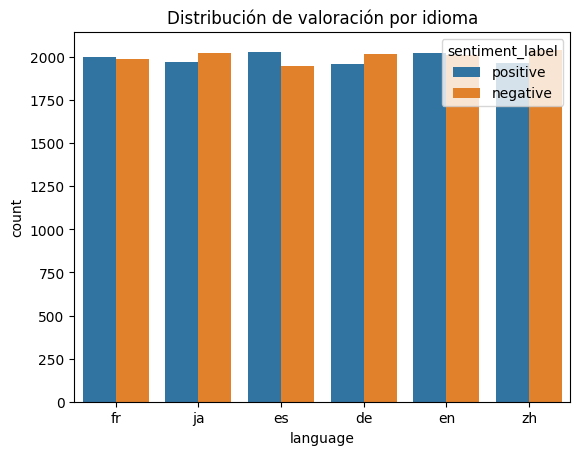

In [13]:
sns.countplot(data=df, x='language', hue='sentiment_label')
plt.title('Distribución de valoración por idioma')
plt.show()

La distribución por **valoración** muestra un buen equilibrio entre reseñas positivas y negativas, sin una dominancia clara, lo es favorable para el entrenamiento de modelos de clasificación, ya que reduce el riesgo de sesgo hacia una clase mayoritaria.

La distribución por **idioma** también es bastante uniforme, lo que permite abordar el problema como un escenario multilingüe sin necesidad de aplicar técnicas específicas de rebalanceo.

En conjunto, el dataset presenta una **distribución balanceada** tanto en la variable objetivo como en los idiomas, lo que lo hace adecuado para el desarrollo de modelos de análisis de sentimiento multilingüe.

In [14]:
df['product_category'].value_counts()

product_category
home                        2488
wireless                    2254
book                        1776
sports                      1246
apparel                     1178
pc                          1173
beauty                      1122
toy                         1082
home_improvement            1081
kitchen                     1043
drugstore                    975
electronics                  924
automotive                   826
other                        803
digital_ebook_purchase       693
shoes                        645
lawn_and_garden              518
baby_product                 508
office_product               506
pet_products                 499
grocery                      448
furniture                    376
camera                       328
luggage                      242
jewelry                      230
watch                        222
personal_care_appliances     180
industrial_supplies          177
video_games                  171
digital_video_download    

In [15]:
df['product_category'].value_counts(normalize=True)

product_category
home                        0.103762
wireless                    0.094003
book                        0.074068
sports                      0.051964
apparel                     0.049128
pc                          0.048920
beauty                      0.046793
toy                         0.045125
home_improvement            0.045083
kitchen                     0.043498
drugstore                   0.040662
electronics                 0.038535
automotive                  0.034448
other                       0.033489
digital_ebook_purchase      0.028901
shoes                       0.026900
lawn_and_garden             0.021603
baby_product                0.021186
office_product              0.021103
pet_products                0.020811
grocery                     0.018684
furniture                   0.015681
camera                      0.013679
luggage                     0.010093
jewelry                     0.009592
watch                       0.009258
personal_care_applian

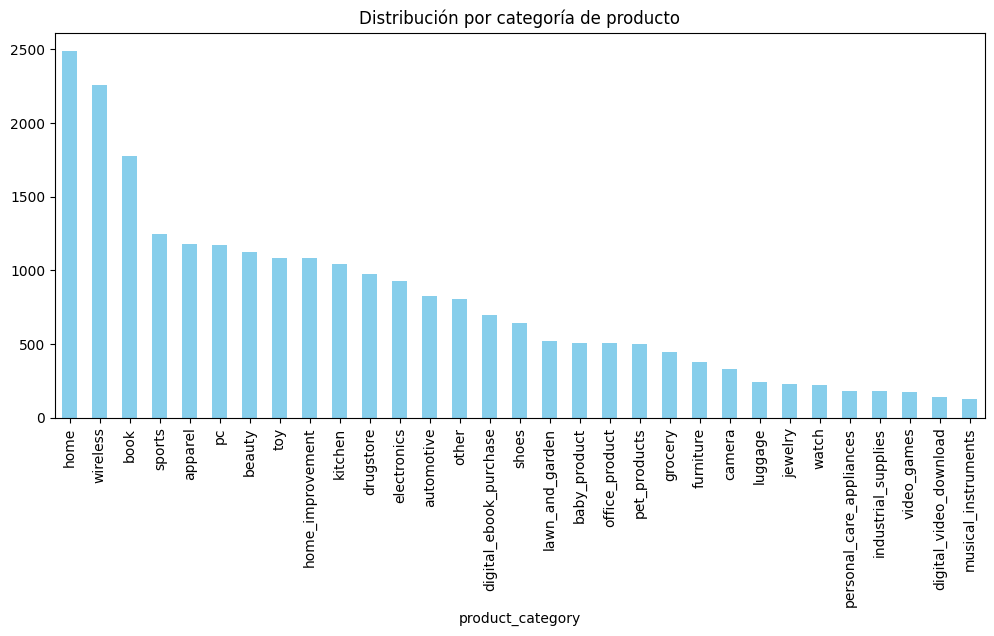

In [16]:
df['product_category'].value_counts().plot(kind='bar', figsize=(12,5), color='skyblue')
plt.title('Distribución por categoría de producto')
plt.show()

La distribución de reviews por **categoría** muestra una estructura relativamente homogénea, con una ligera cola larga (long-tail). La categoría más representada (home) concentra alrededor del 10% del total, mientras que la menos representada (musical instruments) supone aproximadamente el 0.5%.

Dado que ninguna categoría domina el dataset (+15%), no se considera necesario aplicar técnicas de reequilibrado en esta fase exploratoria.

Para análisis posteriores por categoría, podría ser útil agrupar aquellas con menor representación para mejorar la estabilidad de los resultados.

## 2.3. Longitud de las reviews

In [17]:
df['char_length'] = df['review_body'].str.len()
df['char_length'].describe()

count    23978.000000
mean       140.319251
std        145.232533
min         15.000000
25%         47.000000
50%        100.000000
75%        176.000000
max       2466.000000
Name: char_length, dtype: float64

In [18]:
df['char_length'].quantile([0.90, 0.95, 0.99])

0.90    298.00
0.95    405.15
0.99    715.46
Name: char_length, dtype: float64

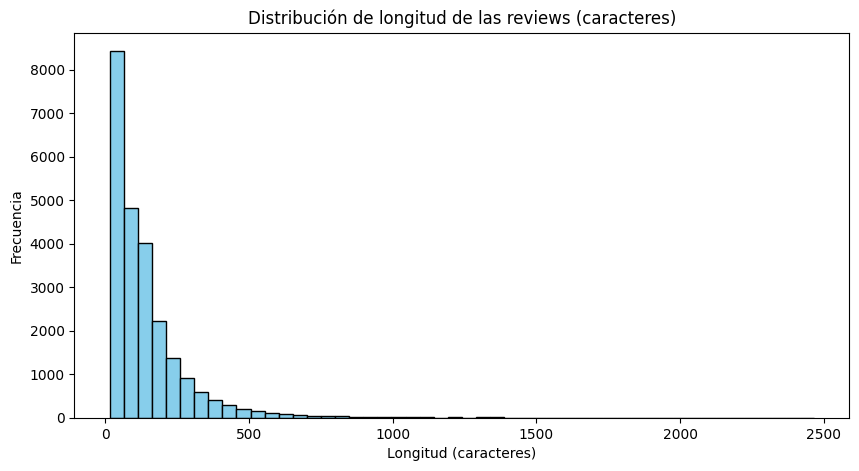

In [19]:
plt.figure(figsize=(10,5))
plt.hist(df['char_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de longitud de las reviews (caracteres)')
plt.xlabel('Longitud (caracteres)')
plt.ylabel('Frecuencia')
plt.show()

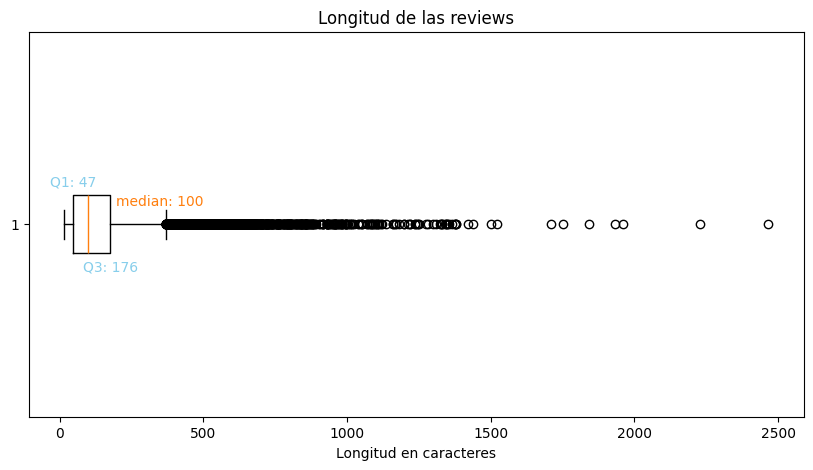

In [20]:
Q1 = df['char_length'].quantile(0.25)
median = df['char_length'].quantile(0.5)
Q3 = df['char_length'].quantile(0.75)

plt.figure(figsize=(10,5))
plt.boxplot(df['char_length'], vert=False)
plt.title('Longitud de las reviews')
plt.text(Q1, 1.1, f'Q1: {int(Q1)}', ha='center', color='skyblue')
plt.text(median +250, 1.05, f'median: {int(median)}', ha='center', color='#ff7f0e')
plt.text(Q3, 0.88, f'Q3: {int(Q3)}', ha='center', color='skyblue')


plt.xlabel('Longitud en caracteres')
plt.show()

La longitud de las reviews se analiza en caracteres como aproximación inicial. El 90% de las reviews tiene menos de 298 caracteres, mientras que solo el 5% supera los 405 caracteres y aproximadamente el 1% supera los 715 caracteres. Esto indica una distribución con cola larga moderada.

El boxplot confirma esta tendencia, con una mediana cercana a 100 caracteres, un rango intercuartílico entre Q1 = 47 y Q3 = 176, y presencia de outliers consistentes con la cola larga observada.

## 2.4. Calidad del texto

In [21]:
short_reviews = df[df['char_length'] < 20]
print(f'Número total de reviews de menos de 20 caracteres: {len(short_reviews)}\n')
print(short_reviews['review_body'].head(10))


Número total de reviews de menos de 20 caracteres: 21

2485       喜欢 喜欢 喜欢 喜欢 喜欢 喜欢
2837       裏地の縫製が悪い 解れ糸が気になる
2956       なかなか固まらない リピートはない
5768      中身空でした(汗) 元々空なのかな?
6528        Dには良いかも。 プロには最悪。
8794      良かったです、 対応迅速、 価格相応
9389       使いやすかったです！ 安いし最高！
9884     color Is bad choice
9910     Funcionan muy bien.
10718    了解金融 了解华尔街 做投资的一定要看
Name: review_body, dtype: str


In [22]:
df['single_word'] = df['review_body'].str.split().apply(lambda x: len(set(x)) == 1)
df['single_word'].mean()

np.float64(0.20731503878555343)

In [23]:
df['weird_chars'] = df.apply(lambda x: rare_chars_european(x['review_body'], x['language']), axis=1)
pct_weird = df['weird_chars'].mean() * 100
print(f"Porcentaje de reviews con caracteres raros: {pct_weird:.2f}%")

Porcentaje de reviews con caracteres raros: 0.04%


In [24]:
weird_reviews = df[df['weird_chars'] == True]
weird_reviews[['review_body', 'language']].head(10)

,review_body,language
893,… avoir une réception par les LNB convenable …...,fr
1264,***Corrijo mi opinión después de haber usado l...,es
9175,+ sehr schnelle Lieferung + Artikel wie abgebi...,de
12737,😁 funktioniert super,de
13737,¡Una porquería! Se rompe con facilidad y ya no...,es
14808,#Avoid - I am returning mine. I connected it t...,en
19344,+ Die Stulpen sehen edel aus. + Als Ergänzung ...,de
20660,• super weich • riecht gar nicht nach Chimie •...,de
21022,👍🏽 Saved a lot of money by doing it myself. My...,en
21599,+ sieht gut aus +wärmt die Hände mit 3 Stufen ...,de


In [25]:
# Patrón combinado con emails, URL y emojis (Unicode rangos comunes)
pattern = r'([a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,})|' \
          r'(https?://\S+|www\.\S+)|' \
          r'([\U0001F300-\U0001F6FF\U0001F900-\U0001F9FF\U0001F1E0-\U0001F1FF])'

# columna booleana
df['has_special'] = df['review_body'].str.contains(pattern)

# porcentaje de reviews con alguno de estos casos
pct_special = df['has_special'].mean() * 100
print(f"Porcentaje de reviews con emails, URLs o emojis: {pct_special:.2f}%")

# ejemplos
df[df['has_special']][['review_body', 'language']].sample(10, random_state=42)


Porcentaje de reviews con emails, URLs o emojis: 0.79%


/var/folders/78/6h09xc011_v8fp6455pxnjmc0000gn/T/ipykernel_15086/2077956952.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_special'] = df['review_body'].str.contains(pattern)


,review_body,language
23842,Merci coco grâce à toi j'ai enfin pu lire enco...,fr
21563,Acheté pour mes enfants de 9 ans et 7 ans Cont...,fr
2055,超出预期的音质和超级变态的续航能力！到手充满电，到现在几乎没掉电啊，这个也太过分了吧😊，实在...,zh
1763,My kids LOVE this product! We live in an apart...,en
8534,😆良い所😆 とても軽いです。 オレンジ色で可愛くてコードが絡まりません。 😢悪い所😢 スイッ...,ja
14304,Seit über 10 Jahren an meinen Schlüsselbund 👍🏻,de
5924,"Muy grande para ser talla M , de cuerpo , sin ...",es
10598,"Super! Schnelle Lieferung, bisschen chemischer...",de
1846,Ist noch gar nicht geliefert worden 😂,de
18335,やっぱり１番のお気に入りは、可愛い足跡🐾マークです。 軽自動車(ダイハツMOVE)の後部座席...,ja


Se ha realizado un análisis de calidad de las reviews con el objetivo de identificar posibles fuentes de ruido o inconsistencias en el dataset.

### Reviews extremadamente cortas

Solo 21 reviews tienen menos de 20 caracteres, la mayoría en idiomas asiáticos donde la densidad semántica por carácter puede ser mayor. Las pocas observaciones en idiomas europeos contienen poca información relevante.

### Repetición de palabras
Aproximadamente el 20.7% de las reviews contienen palabras repetidas. Este fenómeno es común en datasets de e-commerce y puede introducir ruido, aunque no compromete la calidad general del dataset. En función del modelo, podría considerarse su normalización o filtrado.

### Caracteres especiales por idioma
Se han evaluado caracteres especiales en idiomas europeos, considerando válidos los propios de cada lengua. Las reviews en otros idiomas han sido excluidas de este análisis para evitar falsos positivos.

### Presencia de elementos no textuales
La presencia de emails, URLs o emojis representa aproximadamente el 0.79% del total de reviews. Estos elementos pueden tratarse durante el preprocesamiento según la técnica de NLP utilizada.

### Caracteres raros
Solo el 0.04% de las reviews contiene caracteres raros, lo que indica alta consistencia entre el idioma declarado y el contenido textual.

### Conclusión del análisis de calidad
En conjunto, el dataset presenta una **alta consistencia textual**, con niveles bajos de ruido estructural y una presencia limitada de elementos no estándar.

## 2.5. Normalización del texto

Se define el proceso de normalización de texto previo al modelado para asegurar consistencia en las representaciones y mejorar la calidad de los embeddings.

### Pasos

- Limpieza de espacios y saltos de línea para obtener texto continuo.
- Conversión a minúsculas en idiomas europeos.
- Normalización de caracteres, preservando caracteres específicos de cada idioma.
- Gestión de elementos no textuales (emails, URLs y emojis) según la estrategia de NLP seleccionada.
- Tokenización diferenciada por tipo de idioma:
  - Idiomas europeos: tokenización basada en espacios y puntuación.
  - Idiomas asiáticos: tokenización a nivel de carácter o mediante herramientas específicas.
- Eliminación de stopwords, especialmente en representaciones tipo bag-of-words.

### Objetivo

Este proceso prepara el dataset para su representación vectorial y entrenamiento de modelos, garantizando consistencia entre idiomas y reduciendo ruido en las representaciones textuales.

## 2.6. Estrategia de modelado multilingüe

El dataset presenta una distribución equilibrada entre los 6 idiomas (~4000 reviews por idioma) y una proporción cercana al 50% entre clases positivas y negativas dentro de cada idioma.

### Decisión de modelado

Se adopta un **enfoque multilingüe combinado**, utilizando todas las reviews de forma conjunta independientemente del idioma.

### Justificación

Esta estrategia se basa en los siguientes factores:
- Aprovechamiento completo del dataset sin pérdida de información ni subrepresentación.
- Evita errores y costes asociados a la traducción automática.
- Reduce la complejidad operativa al evitar el entrenamiento de múltiples modelos por idioma.
- Permite transferencia de patrones de sentimiento entre idiomas.
- Facilita la escalabilidad del sistema ante la incorporación de nuevos idiomas.

### Implicaciones

Aunque la tokenización requiere tratamiento específico por grupo lingüístico, el enfoque combinado resulta más eficiente en este caso frente a modelos separados por idioma.


# 3. Preprocesamiento



Como el proyecto implica un modelado con Bag-of-Words y otra con Word2Vec, procederemos al preprocesado en 3 fases:
- limpieza estructural
- preprocesado para Bag-of-Words
- preprocesado para Word2Vec

## 3.1. Limpieza estructural

Se define una función de limpieza base (`clean_base`) que estandariza el texto antes de la vectorización, asegurando la consistencia entre idiomas y modelos.

El proceso incluye:

- Normalización de espacios, saltos de línea y tabs.
- Estandarización de URLs y correos electrónicos mediante tokens `<URL>` y `<EMAIL>`.
- Conversión a minúsculas para idiomas europeos.
- Reemplazo de emojis y emoticonos ASCII por el token `<EMOJI>`.
- Eliminación de signos de puntuación, preservando contracciones y palabras compuestas.
- Preservación de caracteres especiales relevantes en idiomas europeos.
- Tokenización dependiente del idioma:
  - Idiomas europeos: tokenización por espacios.
  - Idiomas asiáticos: tokenización a nivel de carácter.

Esta etapa produce una representación inicial del texto lista para su uso en diferentes estrategias de modelado (Bag-of-Words y Word2Vec).

In [26]:
# aplicar la función fila por fila pasando el idioma
df['text_clean'] = df.apply(lambda x: clean_base(x['review_body'], x['language']), axis=1)

In [27]:
df[['text_clean', 'language']].head()
df.isnull().sum()

review_body         0
language            0
sentiment_label     0
product_category    0
char_length         0
single_word         0
weird_chars         0
has_special         0
text_clean          0
dtype: int64

## 3.2. Preprocesado para Bag-of-Words

A partir del texto ya normalizado, se construye una representación Bag-of-Words para modelos clásicos de clasificación.

In [28]:
df['tokens_bow'] = df.apply(lambda x: preprocess_bow(x['text_clean'], x['language']), axis=1)

In [29]:
X_bow, vectorizer = build_bow_matrix(df)

In [30]:
# comprobar forma de la matriz
print("Shape BoW matrix:", X_bow.shape)

# ver vocabulario
print("Ejemplo de vocabulario:", list(vectorizer.vocabulary_.keys())[:10])

Shape BoW matrix: (23978, 17725)
Ejemplo de vocabulario: ['très', 'contente', 'en', 'ai', 'acheté', 'car', 'mes', 'ont', 'ordinateur', 'école']


### Preprocesamiento específico

Se aplica una capa adicional de filtrado mediante la eliminación de stopwords por idioma:
- Inglés: stopwords de sklearn
- Español, francés y alemán: listas específicas definidas manualmente

Este paso reduce ruido léxico y mejora la calidad del vocabulario.

### Construcción de la representación

Cada review se transforma en:
1. Lista de tokens filtrados (`tokens_bow`)
2. String de tokens separado por espacios (`text_bow_final`)

Este formato es requerido por `CountVectorizer`, que genera una matriz de frecuencias.

### Resultado

Se obtiene una matriz sparse de dimensión (n_reviews × vocabulario), utilizada como entrada para modelos de clasificación.

## 3.3. Preprocesado para Word2Vec

Para Word2Vec se utiliza directamente la salida de la limpieza base (`clean_base()`), ya que este modelo se beneficia del contexto de las palabras en lugar de representaciones basadas en frecuencia.

En este caso, no se eliminan stopwords de forma adicional, ya que pueden aportar información contextual.

In [31]:
df['tokens_w2v'] = prepare_w2v_tokens(df)

Se comparan dos enfoques de representación de texto:

- **Bag-of-Words**: representación basada en **frecuencias**, que genera vectores dispersos y no captura relaciones semánticas.
- **Word2Vec**: representación densa basada en **embeddings** que capturan relaciones semánticas a partir del contexto.

Ambas representaciones se utilizarán para entrenar modelos de clasificación y analizar su impacto en el rendimiento del análisis de sentimiento.


# 4. Preparación de datos para el entrenamiento

In [32]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment_label'])  # positive=1, negative=0 (por defecto)

In [33]:
print(le.classes_)

['negative' 'positive']


In [34]:
# split único para una comparación justa (los modelos trabajarán a partir de los mismos datos)
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    np.arange(len(y)),  # indices
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# aplicamos índices a BoW y Word2Vec
X_train_bow = X_bow[X_train_idx]
X_test_bow = X_bow[X_test_idx]

X_train_tokens = df['tokens_w2v'].iloc[X_train_idx]
X_test_tokens = df['tokens_w2v'].iloc[X_test_idx]


La variable objetivo se transforma a formato numérico mediante Label Encoding para su uso en modelos de clasificación.

Posteriormente, se realiza un único particionado del dataset en train (80%) y test (20%), utilizando stratify para mantener la distribución de clases.

Este único split se aplica de forma consistente a todas las representaciones (BoW y Word2Vec), garantizando una comparación justa entre modelos.

# 5. Entrenamiento Bag-of-Words

La representación Bag-of-Words permite utilizar modelos clásicos de Machine Learning sobre una matriz sparse de frecuencias.

Se evaluarán tres clasificadores:
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

Todos los modelos se entrenan utilizando el mismo split train/test para garantizar comparabilidad.

## 5.1. Logistic Regression

In [35]:
bow_lr, metrics_bow_lr, y_pred_bow_lr = run_experiment(
    LogisticRegression(
        max_iter=1000, 
        random_state=42
    ),
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "BoW",
    "LogisticRegression"
)

metrics_bow_lr

,Representación,Clasificador,Accuracy,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,F1 macro
0,BoW,LogisticRegression,0.73,0.68,0.84,0.9,0.57,0.77,0.68,0.73


Logistic Regression obtiene el mejor rendimiento sobre la representación BoW, con un accuracy cercano al 73%.

El modelo presenta un recall significativamente mayor para la clase 0 que para la clase 1, indicando mayor sensibilidad hacia patrones asociados a la clase negativa.

In [36]:
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train_bow, y_train)
print("Mejor C:", grid.best_params_)
y_pred_best = grid.predict(X_test_bow)

Mejor C: {'C': 1}


Se realiza una búsqueda de hiperparámetros sobre el parámetro de regularización `C` mediante validación cruzada.

El valor óptimo encontrado fue `C=1`, coincidiendo con el valor por defecto, por lo que no se observan mejoras adicionales en el conjunto de test.

## 5.2. Random Forest

In [37]:
bow_rf, metrics_bow_rf, y_pred_bow_rf = run_experiment(
    RandomForestClassifier(
        n_estimators=200, # número de árboles
        max_depth=None, # profundidad máxima, None = crecer hasta hojas puras
        random_state=42,
        n_jobs=-1 # usa todos los núcleos disponibles
        ),
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "BoW",
    "RandomForest"
)

metrics_bow_rf

,Representación,Clasificador,Accuracy,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,F1 macro
0,BoW,RandomForest,0.72,0.67,0.84,0.9,0.55,0.77,0.66,0.71


Random Forest obtiene un rendimiento similar al baseline lineal, sin mejoras relevantes en accuracy ni balance entre clases.

Esto sugiere que la representación BoW favorece modelos lineales simples frente a modelos basados en árboles para este problema.

## 5.3. SVM

In [38]:
bow_svm, metrics_bow_svm, y_pred_bow_svm = run_experiment(
    SVC(
        kernel='linear', 
        C=1, 
        random_state=42
        ),
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "BoW",
    "SVM"
)

metrics_bow_svm

,Representación,Clasificador,Accuracy,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,F1 macro
0,BoW,SVM,0.72,0.67,0.82,0.88,0.56,0.76,0.66,0.71


SVM lineal muestra un rendimiento comparable a Random Forest y ligeramente inferior a Logistic Regression.

El comportamiento por clases mantiene el mismo patrón observado anteriormente, con mejor recuperación de la clase 0 que de la clase 1.

## 5.4. Conclusiones sobre Bag-of-Words

La representación BoW permite obtener resultados sólidos utilizando modelos clásicos de Machine Learning.

Entre los modelos evaluados, Logistic Regression ofrece el mejor equilibrio entre rendimiento y simplicidad, mientras que Random Forest y SVM no aportan mejoras significativas.

En todos los casos se observa una menor sensibilidad hacia la clase 1, lo que sugiere limitaciones de la representación basada únicamente en frecuencias.

# 6. Entrenamiento Word2Vec

Se entrena un modelo Word2Vec utilizando únicamente el conjunto de entrenamiento para evitar data leakage.

El modelo aprende embeddings densos de palabras a partir de su contexto, que posteriormente se utilizan para construir representaciones vectoriales de cada review.

In [39]:
w2v_model = Word2Vec(
    sentences=X_train_tokens.tolist(), # solo train para evitar data leakage
    vector_size=100, # tamaño del embedding, suele ser entre 100 y 300
    window=5, # contexto (5 palabras de cada lado)
    min_count=2, # ignorar palabras muy raras
    workers=4, # núcleos para entrenamiento
    seed=42
)

In [40]:
X_train_w2v = np.vstack([review_vector(t, w2v_model) for t in X_train_tokens])
X_test_w2v = np.vstack([review_vector(t, w2v_model) for t in X_test_tokens])

Cada review se representa mediante el promedio de los embeddings de sus palabras presentes en el vocabulario entrenado.

Este procedimiento permite transformar documentos de longitud variable en vectores de tamaño fijo compatibles con modelos clásicos de clasificación.

## 6.1. Logistic Regression

In [41]:
w2v_lr, metrics_w2v_lr, y_pred_w2v_lr = run_experiment(
    LogisticRegression(
        max_iter=1000, 
        random_state=42
        ),
    X_train_w2v,
    X_test_w2v,
    y_train,
    y_test,
    "Word2Vec",
    "LogisticRegression"
)

metrics_w2v_lr

,Representación,Clasificador,Accuracy,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,F1 macro
0,Word2Vec,LogisticRegression,0.68,0.68,0.68,0.69,0.67,0.69,0.68,0.68


Logistic Regression obtiene un accuracy cercano al 67%, mostrando un comportamiento más equilibrado entre clases que los modelos entrenados sobre BoW.

Sin embargo, el rendimiento global es inferior, lo que sugiere que el promedio de embeddings reduce parte de la información discriminativa presente en palabras clave específicas.

## 6.2. Random Forest

In [42]:
w2v_rf, metrics_w2v_rf, y_pred_w2v_rf = run_experiment(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_train_w2v,
    X_test_w2v,
    y_train,
    y_test,
    "Word2Vec",
    "RandomForest"
)

metrics_w2v_rf

,Representación,Clasificador,Accuracy,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,F1 macro
0,Word2Vec,RandomForest,0.67,0.67,0.68,0.68,0.67,0.68,0.67,0.67


Random Forest alcanza el mejor rendimiento entre los modelos entrenados sobre Word2Vec, aunque sigue por debajo de los resultados obtenidos con Bag-of-Words.


## 6.3. SVM

In [43]:
w2v_svm, metrics_w2v_svm, y_pred_w2v_svm = run_experiment(
    SVC(
        kernel='linear', 
        C=1, 
        random_state=42
        ),
    X_train_w2v,
    X_test_w2v,
    y_train,
    y_test,
    "Word2Vec",
    "SVM"
)

metrics_w2v_svm

,Representación,Clasificador,Accuracy,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,F1 macro
0,Word2Vec,SVM,0.68,0.67,0.69,0.7,0.66,0.69,0.67,0.68


SVM obtiene un rendimiento similar al de Logistic Regression sobre Word2Vec, manteniendo un comportamiento equilibrado entre clases pero sin superar los resultados obtenidos con BoW.

## 6.4. Conclusiones sobre Word2Vec

La representación Word2Vec proporciona embeddings densos y semánticos, generando modelos con comportamiento más equilibrado entre clases.

No obstante, en este dataset los modelos entrenados sobre Word2Vec no superan el rendimiento obtenido con Bag-of-Words. Esto sugiere que las palabras clave específicas tienen un peso importante en la clasificación del sentimiento y que el promedio de embeddings suaviza parte de esa información discriminativa.

# 7. Tabla de resultados

Se consolidan las métricas principales de todos los modelos evaluados sobre las representaciones Bag-of-Words y Word2Vec promedio.

La tabla permite comparar el impacto tanto de la representación del texto como del clasificador utilizado.

In [44]:
results = pd.concat([
    get_metrics(y_test, y_pred_bow_lr, "BoW", "LogisticRegression"),
    get_metrics(y_test, y_pred_bow_rf, "BoW", "RandomForest"),
    get_metrics(y_test, y_pred_bow_svm, "BoW", "SVM"),
    get_metrics(y_test, y_pred_w2v_lr, "Word2Vec", "LogisticRegression"),
    get_metrics(y_test, y_pred_w2v_rf, "Word2Vec", "RandomForest"),
    get_metrics(y_test, y_pred_w2v_svm, "Word2Vec", "SVM")
], ignore_index=True)

results_sorted = results.sort_values(by="F1 macro", ascending=False)

results_sorted

,Representación,Clasificador,Accuracy,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,F1 macro
0,BoW,LogisticRegression,0.73,0.68,0.84,0.90,0.57,0.77,0.68,0.73
1,BoW,RandomForest,0.72,0.67,0.84,0.90,0.55,0.77,0.66,0.71
2,BoW,SVM,0.72,0.67,0.82,0.88,0.56,0.76,0.66,0.71
3,Word2Vec,LogisticRegression,0.68,0.68,0.68,0.69,0.67,0.69,0.68,0.68
5,Word2Vec,SVM,0.68,0.67,0.69,0.70,0.66,0.69,0.67,0.68
4,Word2Vec,RandomForest,0.67,0.67,0.68,0.68,0.67,0.68,0.67,0.67


Los modelos entrenados sobre Bag-of-Words obtienen el mejor rendimiento global en este dataset, especialmente con Logistic Regression.

Word2Vec promedio produce métricas más equilibradas entre clases, aunque con menor accuracy y F1-score general.

Entre los clasificadores evaluados, Logistic Regression ofrece el mejor equilibrio entre rendimiento y simplicidad.

# 8. Conclusión

En este proyecto se compararon distintas representaciones de texto y clasificadores clásicos para una tarea multilingüe de sentiment analysis sobre reviews de Amazon.

Los resultados muestran que los modelos entrenados con Bag-of-Words obtienen el mejor rendimiento global, alcanzando hasta un 73% de accuracy con Logistic Regression. En contraste, Word2Vec promedio genera métricas más equilibradas entre clases, aunque con menor rendimiento general. 

Estos resultados sugieren que, para este dataset, las palabras clave discriminativas tienen un peso importante en la clasificación y que representaciones basadas en frecuencia pueden resultar más efectivas que embeddings promedio.

**Logistic Regression entrenado sobre Bag-of-Words se selecciona como modelo final, al ofrecer el mejor equilibrio entre rendimiento, simplicidad y eficiencia computacional.**

El objetivo principal del proyecto fue comparar representaciones y clasificadores bajo un pipeline común y reproducible, más que realizar una optimización exhaustiva de hiperparámetros. Aun así, se realizó una búsqueda básica sobre Logistic Regression sin mejoras significativas respecto a la configuración por defecto.

Como líneas futuras, podrían explorarse técnicas más avanzadas, incluyendo ajuste sistemático de hiperparámetros y embeddings contextuales como BERT, capaces de capturar relaciones semánticas más complejas dentro del texto.

# 9. Guardado

In [45]:
Path(PROJECT_ROOT / "models/bow").mkdir(parents=True, exist_ok=True)
Path(PROJECT_ROOT / "models/w2v").mkdir(parents=True, exist_ok=True)
Path(PROJECT_ROOT / "results").mkdir(parents=True, exist_ok=True)

In [46]:
joblib.dump(bow_lr, PROJECT_ROOT / "models/bow/bow_lr.pkl")
joblib.dump(bow_rf, PROJECT_ROOT / "models/bow/bow_rf.pkl")
joblib.dump(bow_svm, PROJECT_ROOT / "models/bow/bow_svm.pkl")

joblib.dump(vectorizer, PROJECT_ROOT / "models/bow/bow_vectorizer.pkl")

joblib.dump(w2v_lr, PROJECT_ROOT / "models/w2v/w2v_lr.pkl")
joblib.dump(w2v_rf, PROJECT_ROOT / "models/w2v/w2v_rf.pkl")
joblib.dump(w2v_svm, PROJECT_ROOT / "models/w2v/w2v_svm.pkl")

w2v_model.save(str(PROJECT_ROOT / "models/w2v/word2vec.model"))

results_sorted.to_csv(PROJECT_ROOT / "results/model_comparison.csv", index=False)

In [47]:
results_sorted.to_csv("../results/model_comparison.csv", index=False)